In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Upload M7_Data.csv
df = pd.read_csv("https://raw.githubusercontent.com/ruvacynthia/DAV-6150/refs/heads/main/M7_Data.csv")

In [2]:
df.describe()

,loyalty,ID,age,city,LOR,prod_A,type_A,type_B,prod_B,turnover_A,turnover_B,contract,age_P,lor_M
count,14016.000000,14016.000000,14016.000000,14016.000000,14016.000000,14016.000000,14016.000000,14016.000000,14016.000000,14016.000000,14016.000000,14016.0,14016.000000,14016.000000
mean,50.381778,37672.440068,35.882920,-710.950128,0.926299,0.533818,1.607877,1.918878,0.599458,379.161320,328.628207,2.0,35.882920,14.115582
std,48.471790,44855.639209,12.974634,26702.329184,0.965212,0.498873,1.508991,1.686038,0.490026,92.612207,475.616525,0.0,12.974634,11.582550
min,0.000000,1.000000,5.000000,-999999.000000,0.000000,0.000000,0.000000,0.000000,0.000000,300.095909,191.962852,2.0,5.000000,3.000000
25%,2.000000,6741.500000,25.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.919412,219.406925,2.0,25.000000,3.000000
50%,3.000000,13514.500000,33.000000,2.000000,1.000000,1.000000,3.000000,3.000000,1.000000,367.891493,237.656757,2.0,33.000000,15.000000
75%,99.000000,62738.000000,43.000000,2.000000,1.000000,1.000000,3.000000,3.000000,1.000000,399.744924,264.131538,2.0,43.000000,15.000000
max,99.000000,151811.000000,102.000000,235.000000,6.000000,1.000000,6.000000,9.000000,1.000000,5568.784139,12249.084770,2.0,102.000000,75.000000


## EDA

In [3]:
# Print the shape of the DataFrame (number of rows and columns)
print(f"Dataset shape: {df.shape}")

# Print the number of rows in a formatted way
print(f"Number of rows: {df.shape[0]:,}")

# Print the number of columns
print(f"Number of columns: {df.shape[1]}")

# Display the first 5 rows of the DataFrame to get a glimpse of the data
print("\nFirst 5 rows of the dataset:")
display(df.head())

# Display information about the DataFrame, including data types and non-null values
print("\nDataset info:")
display(df.info())

Dataset shape: (14016, 15)
Number of rows: 14,016
Number of columns: 15

First 5 rows of the dataset:


,TARGET,loyalty,ID,age,city,LOR,prod_A,type_A,type_B,prod_B,turnover_A,turnover_B,contract,age_P,lor_M
0,Y,99,77,66,2,0,0,0,0,0,333.561114,264.721010,2,66,3
1,Y,1,159,45,2,3,1,3,3,1,394.735699,284.904978,2,45,39
2,Y,1,220,42,2,2,1,3,6,1,342.180990,1175.589721,2,42,27
3,Y,99,303,31,2,0,0,0,0,0,453.757916,242.341754,2,31,3
4,Y,99,306,62,2,0,0,0,0,0,384.577469,287.008370,2,62,3



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14016 entries, 0 to 14015
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   TARGET      14016 non-null  object 
 1   loyalty     14016 non-null  int64  
 2   ID          14016 non-null  int64  
 3   age         14016 non-null  int64  
 4   city        14016 non-null  int64  
 5   LOR         14016 non-null  int64  
 6   prod_A      14016 non-null  int64  
 7   type_A      14016 non-null  int64  
 8   type_B      14016 non-null  int64  
 9   prod_B      14016 non-null  int64  
 10  turnover_A  14016 non-null  float64
 11  turnover_B  14016 non-null  float64
 12  contract    14016 non-null  int64  
 13  age_P       14016 non-null  int64  
 14  lor_M       14016 non-null  int64  
dtypes: float64(2), int64(12), object(1)
memory usage: 1.6+ MB


None

In [4]:
# Count exact row duplicates across ALL columns
duplicates = df.duplicated(keep='first').sum()
print(f"Exact duplicate rows (all columns): {duplicates}")

# Check for missing values
df.missing_count=df.isnull().sum()
print(f"Missing values: {df.missing_count}")


Exact duplicate rows (all columns): 3008
Missing values: TARGET        0
loyalty       0
ID            0
age           0
city          0
LOR           0
prod_A        0
type_A        0
type_B        0
prod_B        0
turnover_A    0
turnover_B    0
contract      0
age_P         0
lor_M         0
dtype: int64


/tmp/ipython-input-1426693628.py:6: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.missing_count=df.isnull().sum()


In [5]:
# Convert target to numeric binary
df['TARGET'] = df['TARGET'].map({'Y': 1, 'N': 0})

# Define categorical columns
categorical_cols = ['TARGET','loyalty','city','prod_A','type_A','type_B',
                    'prod_B','contract']

df[categorical_cols] = df[categorical_cols].astype('category')

### EDA Univariate analysis

#### Categorical

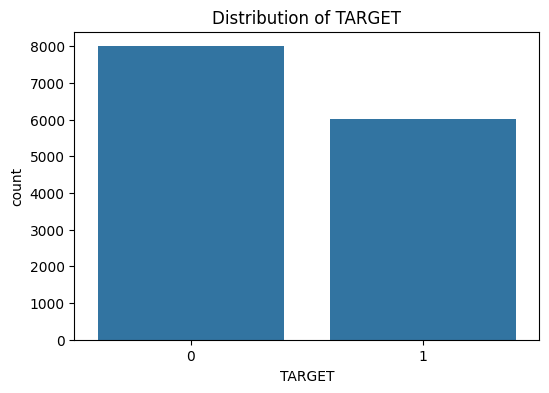

TARGET
0    8000
1    6016
Name: count, dtype: int64 



In [6]:
# Plot for the first categorical column
col = categorical_cols[0]
plt.figure(figsize=(6,4))
sns.countplot(x=df[col])
plt.title(f"Distribution of {col}")
plt.show()
print(df[col].value_counts(), "\n")

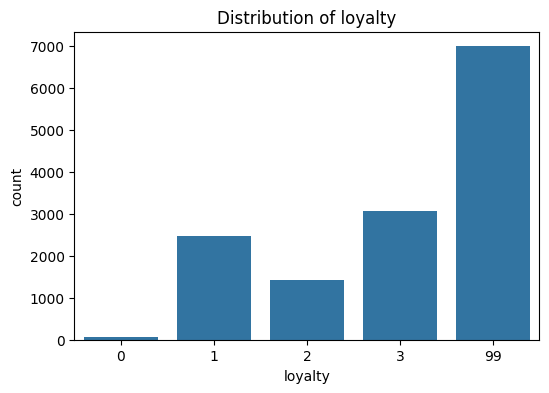

loyalty
99    6986
3     3069
1     2480
2     1425
0       56
Name: count, dtype: int64 



In [7]:
# Plot for the second categorical column
col = categorical_cols[1]
plt.figure(figsize=(6,4))
sns.countplot(x=df[col])
plt.title(f"Distribution of {col}")
plt.show()
print(df[col].value_counts(), "\n")

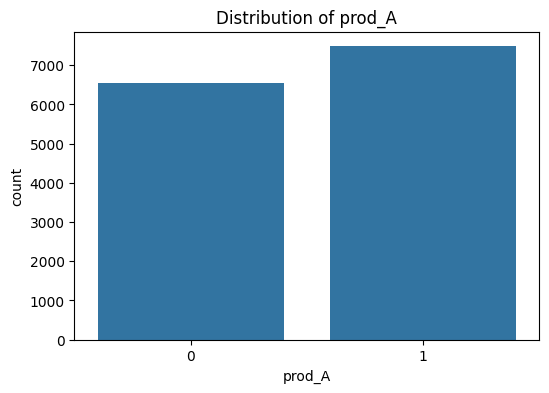

prod_A
1    7482
0    6534
Name: count, dtype: int64 



In [8]:
# Plot for the fourth categorical column
col = categorical_cols[3]
plt.figure(figsize=(6,4))
sns.countplot(x=df[col])
plt.title(f"Distribution of {col}")
plt.show()
print(df[col].value_counts(), "\n")

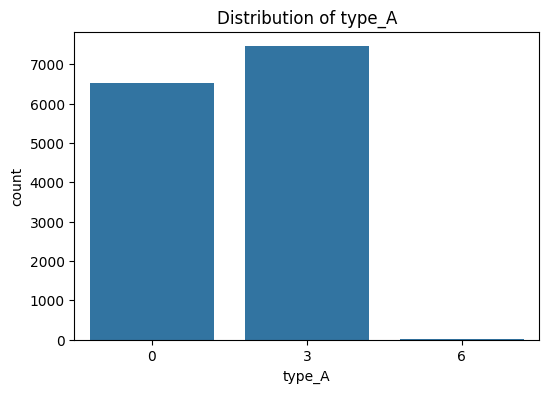

type_A
3    7452
0    6534
6      30
Name: count, dtype: int64 



In [9]:
# Plot for the fifth categorical column
col = categorical_cols[4]
plt.figure(figsize=(6,4))
sns.countplot(x=df[col])
plt.title(f"Distribution of {col}")
plt.show()
print(df[col].value_counts(), "\n")

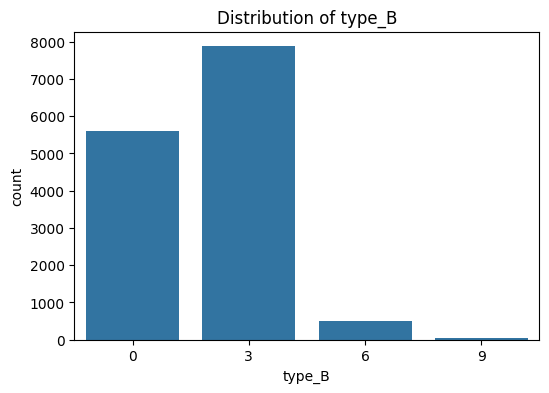

type_B
3    7874
0    5614
6     493
9      35
Name: count, dtype: int64 



In [10]:
# Plot for the 6th categorical column
col = categorical_cols[5]
plt.figure(figsize=(6,4))
sns.countplot(x=df[col])
plt.title(f"Distribution of {col}")
plt.show()
print(df[col].value_counts(), "\n")

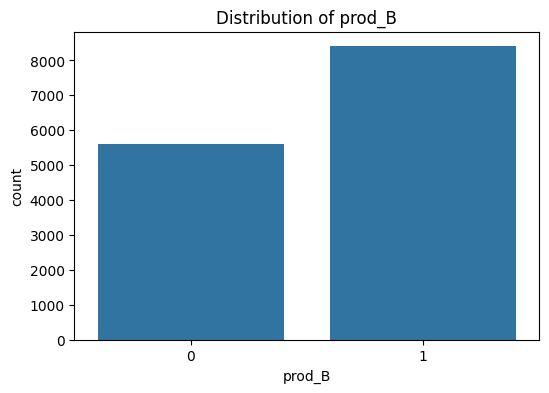

prod_B
1    8402
0    5614
Name: count, dtype: int64 



In [11]:
# Plot for the 7th categorical column
col = categorical_cols[6]
plt.figure(figsize=(6,4))
sns.countplot(x=df[col])
plt.title(f"Distribution of {col}")
plt.show()
print(df[col].value_counts(), "\n")

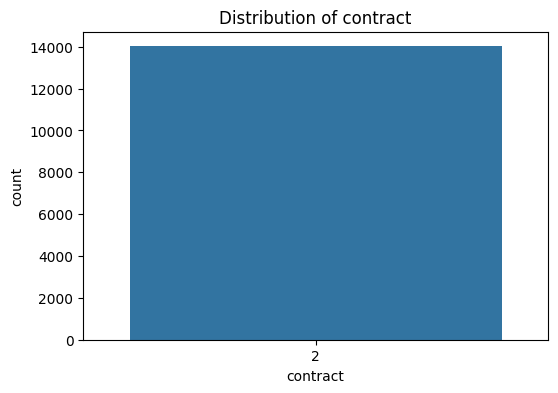

contract
2    14016
Name: count, dtype: int64 



In [12]:
# Plot for the 8th categorical column
col = categorical_cols[7]
plt.figure(figsize=(6,4))
sns.countplot(x=df[col])
plt.title(f"Distribution of {col}")
plt.show()
print(df[col].value_counts(), "\n")

#### EDA for Numeric Variables

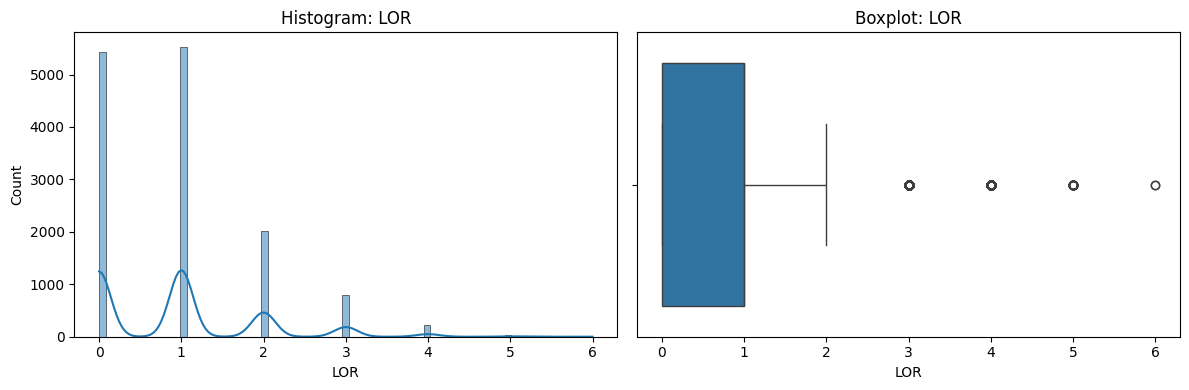

In [13]:
num_cols = ['age','LOR','turnover_A','turnover_B','age_P','lor_M']

col = num_cols[1]
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df[col], kde=True)
plt.title(f"Histogram: {col}")

plt.subplot(1, 2, 2)
sns.boxplot(x=df[col])
plt.title(f"Boxplot: {col}")

plt.tight_layout()
plt.show()

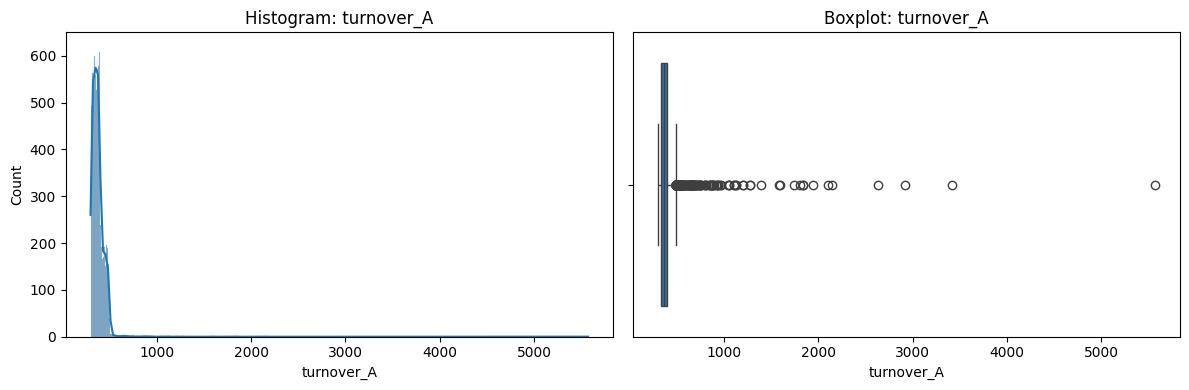

In [14]:
num_cols = ['age','LOR','turnover_A','turnover_B','age_P','lor_M']

col = num_cols[2]
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df[col], kde=True)
plt.title(f"Histogram: {col}")

plt.subplot(1, 2, 2)
sns.boxplot(x=df[col])
plt.title(f"Boxplot: {col}")

plt.tight_layout()
plt.show()

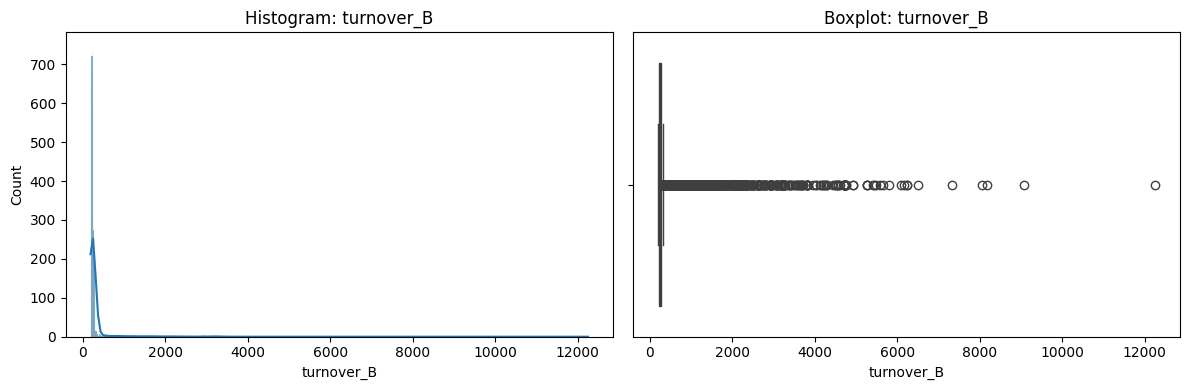

In [15]:
num_cols = ['age','LOR','turnover_A','turnover_B','age_P','lor_M']

col = num_cols[3]
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df[col], kde=True)
plt.title(f"Histogram: {col}")

plt.subplot(1, 2, 2)
sns.boxplot(x=df[col])
plt.title(f"Boxplot: {col}")

plt.tight_layout()
plt.show()

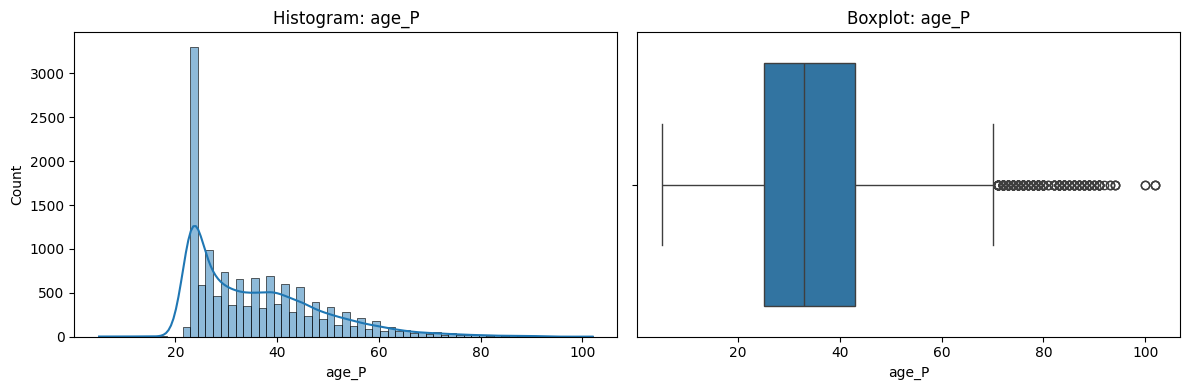

In [16]:
num_cols = ['age','LOR','turnover_A','turnover_B','age_P','lor_M']

col = num_cols[4]
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df[col], kde=True)
plt.title(f"Histogram: {col}")

plt.subplot(1, 2, 2)
sns.boxplot(x=df[col])
plt.title(f"Boxplot: {col}")

plt.tight_layout()
plt.show()

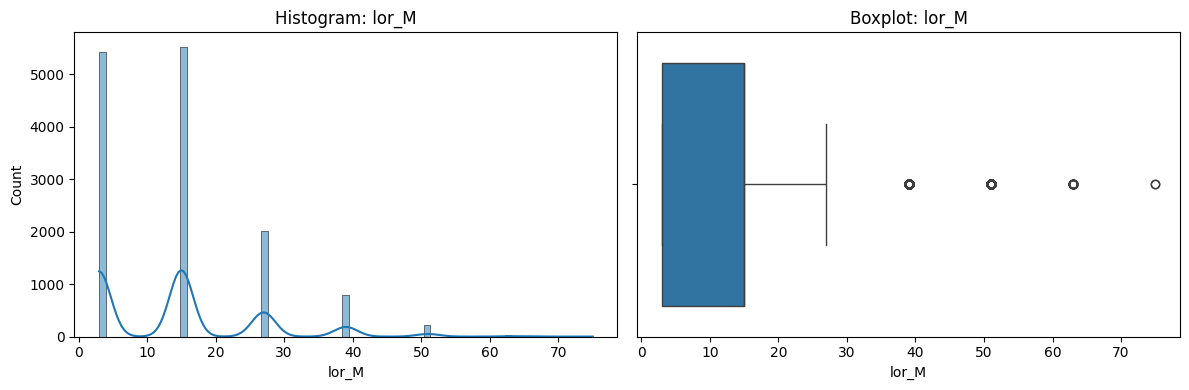

In [17]:
num_cols = ['age','LOR','turnover_A','turnover_B','age_P','lor_M']

col = num_cols[5]
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df[col], kde=True)
plt.title(f"Histogram: {col}")

plt.subplot(1, 2, 2)
sns.boxplot(x=df[col])
plt.title(f"Boxplot: {col}")

plt.tight_layout()
plt.show()

### Bivariate Analysis of TARGET and Numerical Features (Separate Plots)

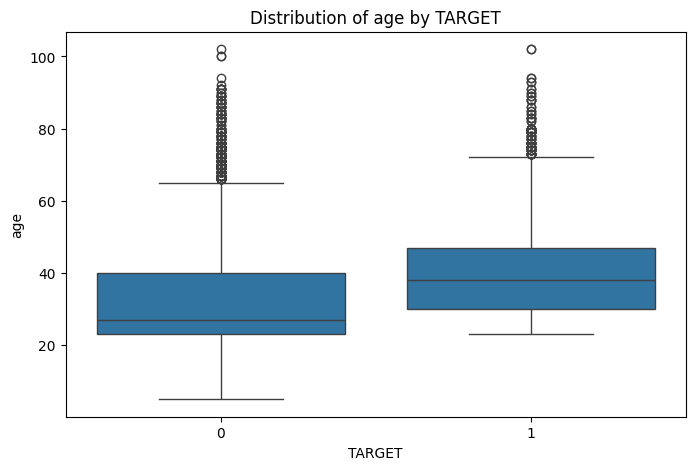

In [18]:
num_cols = ['age','LOR','turnover_A','turnover_B','age_P','lor_M']

# Bivariate analysis of TARGET with 'age'
col = num_cols[0]
plt.figure(figsize=(8, 5))
sns.boxplot(x='TARGET', y=col, data=df)
plt.title(f"Distribution of {col} by TARGET")
plt.show()

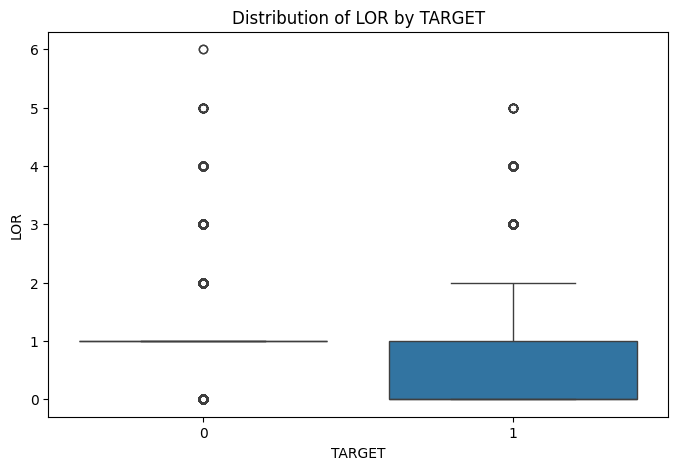

In [19]:
num_cols = ['age','LOR','turnover_A','turnover_B','age_P','lor_M']

# Bivariate analysis of TARGET with 'LOR'
col = num_cols[1]
plt.figure(figsize=(8, 5))
sns.boxplot(x='TARGET', y=col, data=df)
plt.title(f"Distribution of {col} by TARGET")
plt.show()

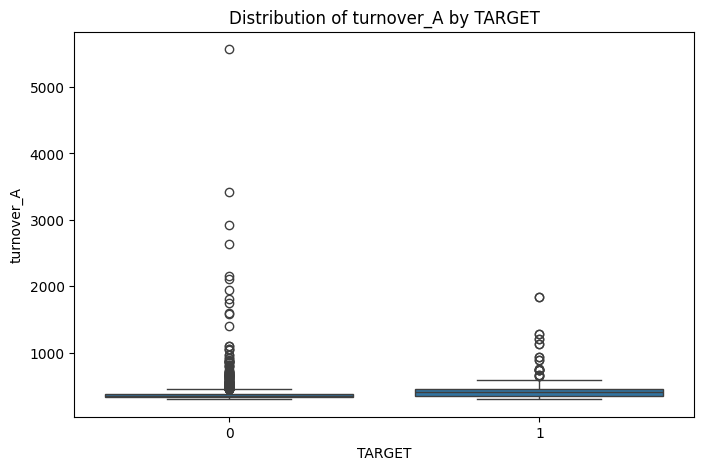

In [20]:
num_cols = ['age','LOR','turnover_A','turnover_B','age_P','lor_M']

# Bivariate analysis of TARGET with 'turnover_A'
col = num_cols[2]
plt.figure(figsize=(8, 5))
sns.boxplot(x='TARGET', y=col, data=df)
plt.title(f"Distribution of {col} by TARGET")
plt.show()

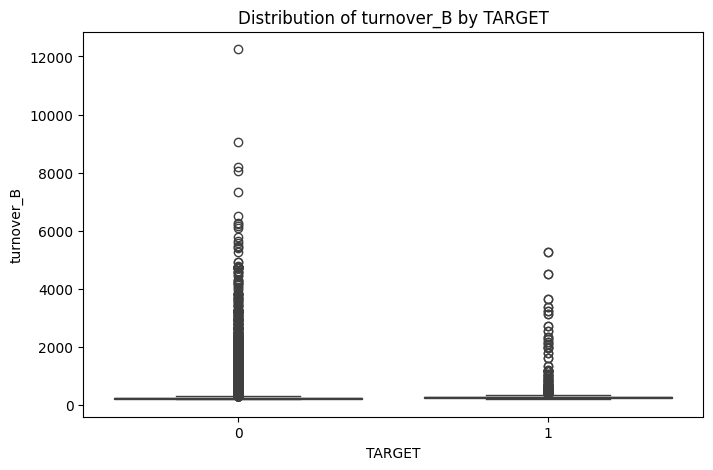

In [21]:
num_cols = ['age','LOR','turnover_A','turnover_B','age_P','lor_M']

# Bivariate analysis of TARGET with 'turnover_B'
col = num_cols[3]
plt.figure(figsize=(8, 5))
sns.boxplot(x='TARGET', y=col, data=df)
plt.title(f"Distribution of {col} by TARGET")
plt.show()

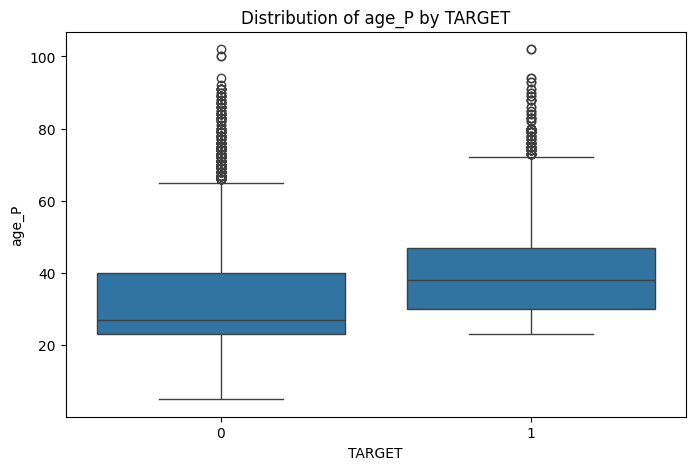

In [22]:
num_cols = ['age','LOR','turnover_A','turnover_B','age_P','lor_M']

# Bivariate analysis of TARGET with 'age_P'
col = num_cols[4]
plt.figure(figsize=(8, 5))
sns.boxplot(x='TARGET', y=col, data=df)
plt.title(f"Distribution of {col} by TARGET")
plt.show()

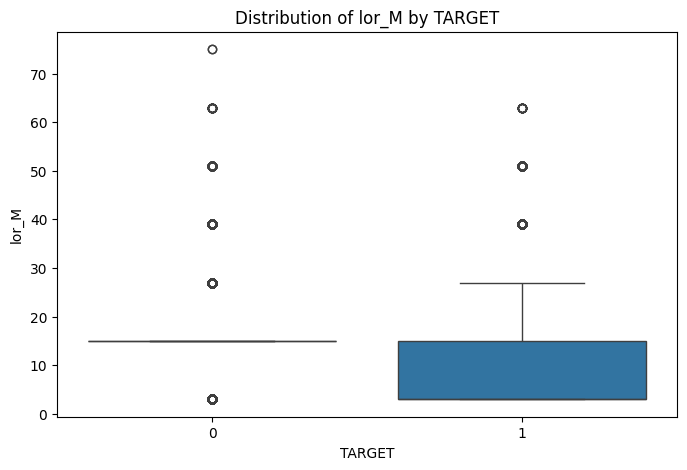

In [23]:
num_cols = ['age','LOR','turnover_A','turnover_B','age_P','lor_M']

# Bivariate analysis of TARGET with 'lor_M'
col = num_cols[5]
plt.figure(figsize=(8, 5))
sns.boxplot(x='TARGET', y=col, data=df)
plt.title(f"Distribution of {col} by TARGET")
plt.show()

### BiVariate for Categorical

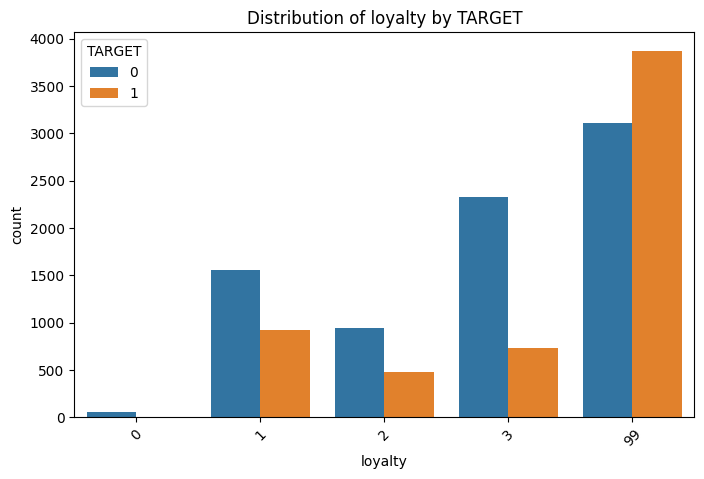

Chi-squared test for loyalty and TARGET:
  Chi2 Statistic: 1022.9098
  P-value: 0.0000
  Degrees of Freedom: 4
------------------------------


In [24]:
from scipy.stats import chi2_contingency

# Bivariate analysis of TARGET with 'loyalty'
col = 'loyalty'
plt.figure(figsize=(8, 5))
sns.countplot(x=col, hue='TARGET', data=df)
plt.title(f"Distribution of {col} by TARGET")
plt.xticks(rotation=45)
plt.show()

# Perform Chi-squared test for 'loyalty' and TARGET
contingency_table = pd.crosstab(df[col], df['TARGET'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-squared test for {col} and TARGET:")
print(f"  Chi2 Statistic: {chi2:.4f}")
print(f"  P-value: {p:.4f}")
print(f"  Degrees of Freedom: {dof}")
print("-" * 30)

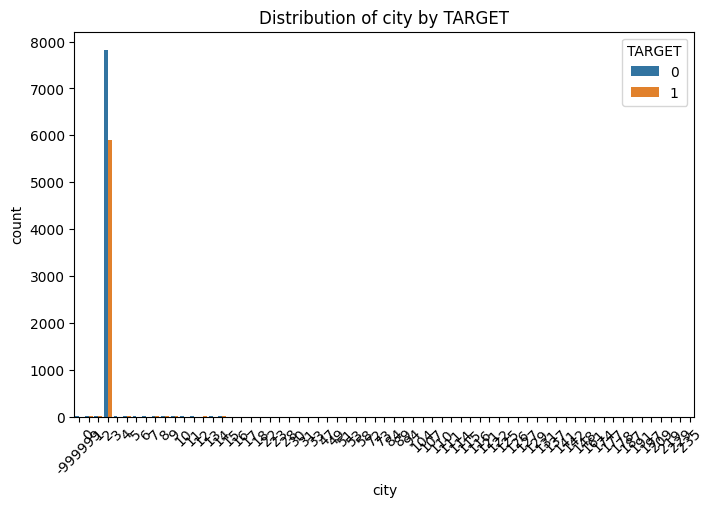

Chi-squared test for city and TARGET:
  Chi2 Statistic: 71.9834
  P-value: 0.2307
  Degrees of Freedom: 64
------------------------------


In [25]:
from scipy.stats import chi2_contingency

# Bivariate analysis of TARGET with 'city'
col = 'city'
plt.figure(figsize=(8, 5))
sns.countplot(x=col, hue='TARGET', data=df)
plt.title(f"Distribution of {col} by TARGET")
plt.xticks(rotation=45)
plt.show()

# Perform Chi-squared test for 'city' and TARGET
contingency_table = pd.crosstab(df[col], df['TARGET'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-squared test for {col} and TARGET:")
print(f"  Chi2 Statistic: {chi2:.4f}")
print(f"  P-value: {p:.4f}")
print(f"  Degrees of Freedom: {dof}")
print("-" * 30)

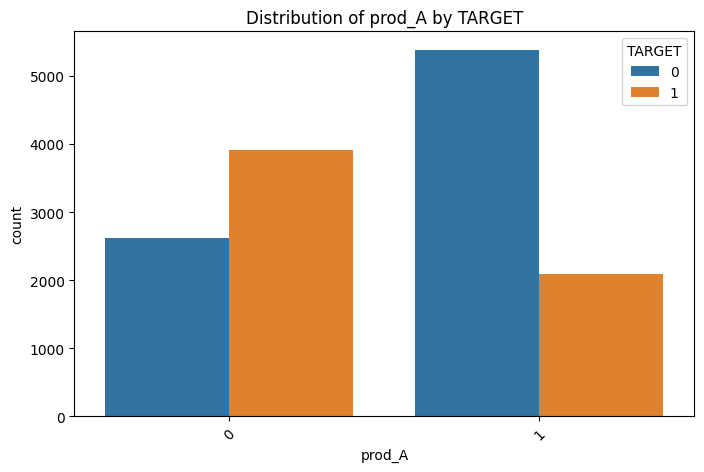

Chi-squared test for prod_A and TARGET:
  Chi2 Statistic: 1449.5411
  P-value: 0.0000
  Degrees of Freedom: 1
------------------------------


In [26]:
from scipy.stats import chi2_contingency

# Bivariate analysis of TARGET with 'prod_A'
col = 'prod_A'
plt.figure(figsize=(8, 5))
sns.countplot(x=col, hue='TARGET', data=df)
plt.title(f"Distribution of {col} by TARGET")
plt.xticks(rotation=45)
plt.show()

# Perform Chi-squared test for 'prod_A' and TARGET
contingency_table = pd.crosstab(df[col], df['TARGET'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-squared test for {col} and TARGET:")
print(f"  Chi2 Statistic: {chi2:.4f}")
print(f"  P-value: {p:.4f}")
print(f"  Degrees of Freedom: {dof}")
print("-" * 30)

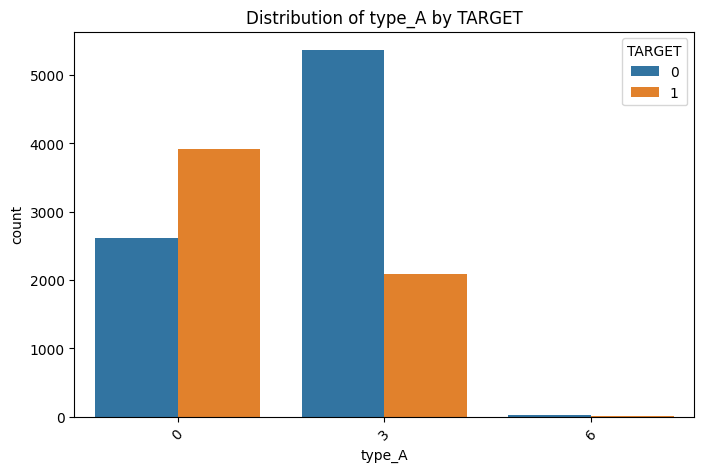

Chi-squared test for type_A and TARGET:
  Chi2 Statistic: 1455.1092
  P-value: 0.0000
  Degrees of Freedom: 2
------------------------------


In [27]:
from scipy.stats import chi2_contingency

# Bivariate analysis of TARGET with 'type_A'
col = 'type_A'
plt.figure(figsize=(8, 5))
sns.countplot(x=col, hue='TARGET', data=df)
plt.title(f"Distribution of {col} by TARGET")
plt.xticks(rotation=45)
plt.show()

# Perform Chi-squared test for 'type_A' and TARGET
contingency_table = pd.crosstab(df[col], df['TARGET'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-squared test for {col} and TARGET:")
print(f"  Chi2 Statistic: {chi2:.4f}")
print(f"  P-value: {p:.4f}")
print(f"  Degrees of Freedom: {dof}")
print("-" * 30)

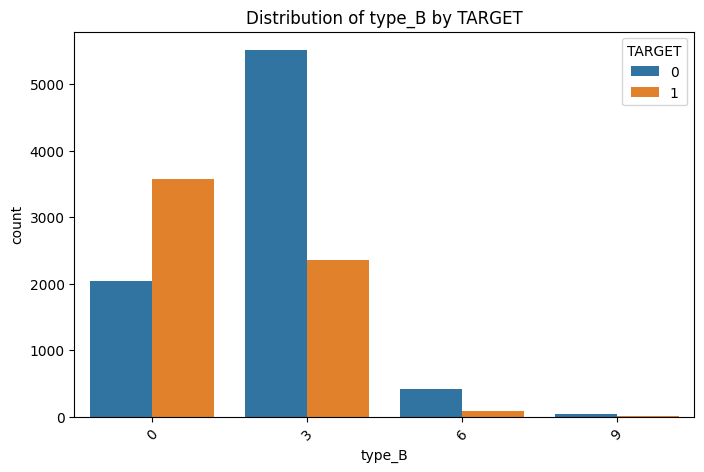

Chi-squared test for type_B and TARGET:
  Chi2 Statistic: 1676.6845
  P-value: 0.0000
  Degrees of Freedom: 3
------------------------------


In [28]:
from scipy.stats import chi2_contingency

# Bivariate analysis of TARGET with 'type_B'
col = 'type_B'
plt.figure(figsize=(8, 5))
sns.countplot(x=col, hue='TARGET', data=df)
plt.title(f"Distribution of {col} by TARGET")
plt.xticks(rotation=45)
plt.show()

# Perform Chi-squared test for 'type_B' and TARGET
contingency_table = pd.crosstab(df[col], df['TARGET'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-squared test for {col} and TARGET:")
print(f"  Chi2 Statistic: {chi2:.4f}")
print(f"  P-value: {p:.4f}")
print(f"  Degrees of Freedom: {dof}")
print("-" * 30)

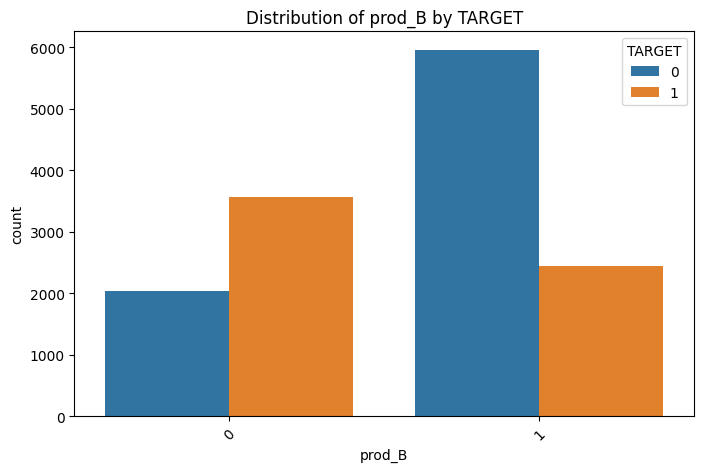

Chi-squared test for prod_B and TARGET:
  Chi2 Statistic: 1637.2328
  P-value: 0.0000
  Degrees of Freedom: 1
------------------------------


In [29]:
from scipy.stats import chi2_contingency

# Bivariate analysis of TARGET with 'prod_B'
col = 'prod_B'
plt.figure(figsize=(8, 5))
sns.countplot(x=col, hue='TARGET', data=df)
plt.title(f"Distribution of {col} by TARGET")
plt.xticks(rotation=45)
plt.show()

# Perform Chi-squared test for 'prod_B' and TARGET
contingency_table = pd.crosstab(df[col], df['TARGET'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-squared test for {col} and TARGET:")
print(f"  Chi2 Statistic: {chi2:.4f}")
print(f"  P-value: {p:.4f}")
print(f"  Degrees of Freedom: {dof}")
print("-" * 30)

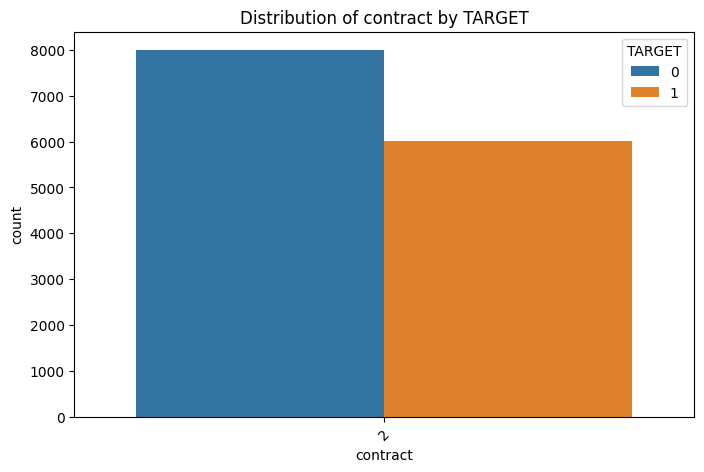

Chi-squared test for contract and TARGET:
  Chi2 Statistic: 0.0000
  P-value: 1.0000
  Degrees of Freedom: 0
------------------------------


In [30]:
from scipy.stats import chi2_contingency

# Bivariate analysis of TARGET with 'contract'
col = 'contract'
plt.figure(figsize=(8, 5))
sns.countplot(x=col, hue='TARGET', data=df)
plt.title(f"Distribution of {col} by TARGET")
plt.xticks(rotation=45)
plt.show()

# Perform Chi-squared test for 'contract' and TARGET
contingency_table = pd.crosstab(df[col], df['TARGET'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-squared test for {col} and TARGET:")
print(f"  Chi2 Statistic: {chi2:.4f}")
print(f"  P-value: {p:.4f}")
print(f"  Degrees of Freedom: {dof}")
print("-" * 30)

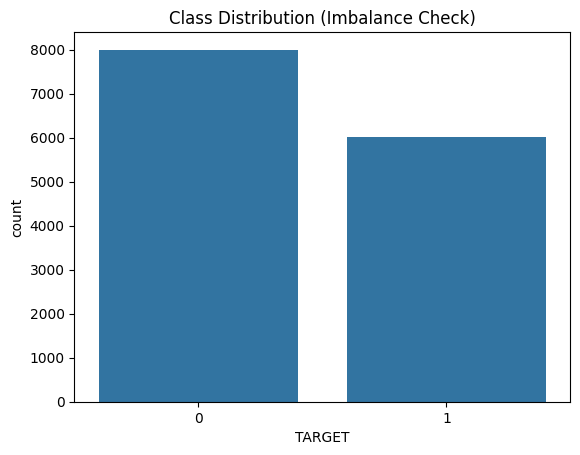

TARGET
0    57.077626
1    42.922374
Name: proportion, dtype: float64


In [31]:
sns.countplot(x=df['TARGET'])
plt.title("Class Distribution (Imbalance Check)")
plt.show()

print(df['TARGET'].value_counts(normalize=True)*100)

### Multivariate analysis

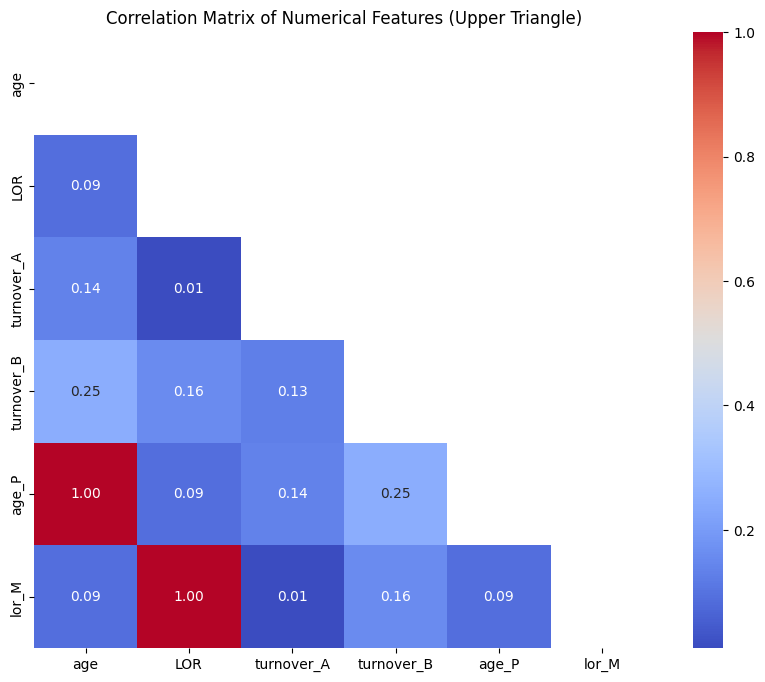

In [32]:
# Calculate the correlation matrix for numerical columns
correlation_matrix = df[num_cols].corr()

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Plot the heatmap of the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", mask=mask)
plt.title("Correlation Matrix of Numerical Features (Upper Triangle)")
plt.show()

In [33]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculate VIF for numerical features
numerical_features = df[num_cols]
vif_data = pd.DataFrame()
vif_data["feature"] = numerical_features.columns

# Calculating VIF for each feature
vif_data["VIF"] = [variance_inflation_factor(numerical_features.values, i)
                   for i in range(len(numerical_features.columns))]

print("\nVIF for numerical features:")
display(vif_data)


VIF for numerical features:


/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,feature,VIF
0,age,inf
1,LOR,686.464804
2,turnover_A,1.029064
3,turnover_B,1.100238
4,age_P,inf
5,lor_M,870.270172


# Data Preparation
Perform data preparation steps for building binary logistic regression models to predict the 'TARGET' variable, including handling categorical variables, duplicates, and feature scaling, and splitting the data into training and testing sets.

In [34]:
#Start clean & remove duplicates
df_clean = df.copy()
n_dups = df_clean.duplicated().sum()
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print(f"Duplicates removed: {n_dups} | New shape: {df_clean.shape}")

Duplicates removed: 3008 | New shape: (11008, 15)


In [35]:
 #Target to int (binary)
df_clean['TARGET'] = df_clean['TARGET'].astype(int)

In [36]:
# Handle sentinel codes & make categoricals uniformly strings ----------
# Loyalty: 0–3 are valid levels; 99 means "unclassified" -> "Unknown"

# Convert 99 to NaN first as loyalty is category
df_clean['loyalty'] = df_clean['loyalty'].replace(99, np.nan)

# Add 'Unknown' to the categories of the loyalty column
if 'Unknown' not in df_clean['loyalty'].cat.categories:
    df_clean['loyalty'] = df_clean['loyalty'].cat.add_categories('Unknown')

# Fill NaN values (which were originally 99) with 'Unknown'
df_clean['loyalty'] = df_clean['loyalty'].fillna('Unknown')

#convert to string after handling categories
df_clean['loyalty'] = df_clean['loyalty'].astype(str)

print("\nLoyalty value counts before handling 99 and NaNs:")
display(df['loyalty'].value_counts())

print("\nLoyalty value counts after handling 99 and NaNs:")
display(df_clean['loyalty'].value_counts())


Loyalty value counts before handling 99 and NaNs:


/tmp/ipython-input-2778815525.py:5: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df_clean['loyalty'] = df_clean['loyalty'].replace(99, np.nan)


,count
loyalty,
99,6986
3,3069
1,2480
2,1425
0,56



Loyalty value counts after handling 99 and NaNs:


,count
loyalty,
Unknown,5048
3,2701
1,2019
2,1184
0,56


In [37]:
# Binary flags & categorical codes -> strings
for c in ['prod_A','type_A','type_B','prod_B','contract','city']:
    df_clean[c] = df_clean[c].astype(str)

In [38]:
#Clip impossible / extreme numeric values
# Bound ages & tenures to plausible ranges
df_clean['age']   = df_clean['age'].clip(lower=0, upper=100)
df_clean['age_P'] = df_clean['age_P'].clip(lower=0, upper=110)
df_clean['LOR']   = df_clean['LOR'].clip(lower=0)
df_clean['lor_M'] = df_clean['lor_M'].clip(lower=0)

In [39]:
#Reconcile tenure to tenure_months
lor_from_years  = df_clean['LOR'] * 12
lor_from_months = df_clean['lor_M']
tenure_months = np.where(
    (lor_from_years.notna() & lor_from_months.notna() &
     (np.abs(lor_from_years - lor_from_months) <= 2)),  # agree within 2 mo
    lor_from_months,
    np.where(lor_from_months.notna(), lor_from_months, lor_from_years)
)
df_clean['tenure_months'] = tenure_months

In [40]:
#Winsorize spend & log-transform
for c in ['turnover_A','turnover_B']:
    q_low, q_hi = df_clean[c].quantile([0.001, 0.999])
    df_clean[c] = df_clean[c].clip(lower=q_low, upper=q_hi)

df_clean['log_turnover_A'] = np.log1p(df_clean['turnover_A'])
df_clean['log_turnover_B'] = np.log1p(df_clean['turnover_B'])

In [41]:
# Reduce high-cardinality city
K = 20
top_cities = df_clean['city'].value_counts().nlargest(K).index
df_clean['city_reduced'] = np.where(df_clean['city'].isin(top_cities), df_clean['city'], 'Other')
df_clean['city_reduced'] = df_clean['city_reduced'].astype(str)

In [42]:
#Drop non-predictive identifiers
df_clean = df_clean.drop(columns=['ID'])

In [43]:
df_clean.head()

,TARGET,loyalty,age,city,LOR,prod_A,type_A,type_B,prod_B,turnover_A,turnover_B,contract,age_P,lor_M,tenure_months,log_turnover_A,log_turnover_B,city_reduced
0,1,Unknown,66,2,0,0,0,0,0,333.561114,264.721010,2,66,3,3,5.812820,5.582447,2
1,1,1,45,2,3,1,3,3,1,394.735699,284.904978,2,45,39,39,5.980747,5.655660,2
2,1,1,42,2,2,1,3,6,1,342.180990,1175.589721,2,42,27,27,5.838258,7.070375,2
3,1,Unknown,31,2,0,0,0,0,0,453.757916,242.341754,2,31,3,3,6.119765,5.494467,2
4,1,Unknown,62,2,0,0,0,0,0,384.577469,287.008370,2,62,3,3,5.954742,5.662990,2


In [44]:
# Lock feature lists you chose-
categorical_for_model = ['loyalty','prod_A','type_A','type_B','prod_B','city_reduced']
numeric_for_model     = ['age','tenure_months','log_turnover_A','log_turnover_B']
target_col = 'TARGET'

In [45]:
# Sanity checks: uniform types (no mixed int/str) ----------
def col_types(series):
    return {type(v).__name__ for v in series.dropna().unique()}

print("\nType audit:")
for c in categorical_for_model:
    print(f"{c} -> {col_types(df_clean[c])}")  # should be {'str'}
for c in numeric_for_model + ['age_P']:  # 'age_P' not modeled but numeric
    print(f"{c} (is numeric):", pd.api.types.is_numeric_dtype(df_clean[c]))


Type audit:
loyalty -> {'str'}
prod_A -> {'str'}
type_A -> {'str'}
type_B -> {'str'}
prod_B -> {'str'}
city_reduced -> {'str'}
age (is numeric): True
tenure_months (is numeric): True
log_turnover_A (is numeric): True
log_turnover_B (is numeric): True
age_P (is numeric): True


In [46]:
# Final modeling frame ----------
df_ready = df_clean[[target_col] + categorical_for_model + numeric_for_model].copy()
print("\nFinal df_ready shape:", df_ready.shape)


Final df_ready shape: (11008, 11)


### Prepped Data Review

In [47]:
df_clean
categorical_for_model = ['loyalty','prod_A','type_A','type_B','prod_B','city_reduced']
numeric_for_model     = ['age','tenure_months','log_turnover_A','log_turnover_B']
target_col = 'TARGET'

Overview: shape, duplicates, dtypes

In [48]:
print("Shape:", df_clean.shape)
print("Duplicate rows (should be 0):", df_clean.duplicated().sum())

Shape: (11008, 18)
Duplicate rows (should be 0): 0


In [49]:
# Dtypes snapshot
dtypes_df = pd.DataFrame({
    'column': df_clean.columns,
    'dtype': df_clean.dtypes.astype(str),
    'n_unique': [df_clean[c].nunique(dropna=True) for c in df_clean.columns]
}).sort_values('column')
dtypes_df

,column,dtype,n_unique
LOR,LOR,int64,7
TARGET,TARGET,int64,2
age,age,int64,85
age_P,age_P,int64,86
city,city,object,65
city_reduced,city_reduced,object,21
contract,contract,object,1
log_turnover_A,log_turnover_A,float64,10986
log_turnover_B,log_turnover_B,float64,10986
lor_M,lor_M,int64,7


Missingness audit (counts & %)

In [50]:
na_counts = df_clean[numeric_for_model + categorical_for_model + [target_col]].isna().sum()
na_pct = (na_counts / len(df_clean) * 100).round(2)
na_table = pd.DataFrame({'n_missing': na_counts, 'pct_missing': na_pct}).sort_values('pct_missing', ascending=False)
na_table

,n_missing,pct_missing
age,0,0.0
tenure_months,0,0.0
log_turnover_A,0,0.0
log_turnover_B,0,0.0
loyalty,0,0.0
prod_A,0,0.0
type_A,0,0.0
type_B,0,0.0
prod_B,0,0.0
city_reduced,0,0.0


Class balance (target)

Class distribution (%):
 TARGET
0    72.67
1    27.33
Name: count, dtype: float64


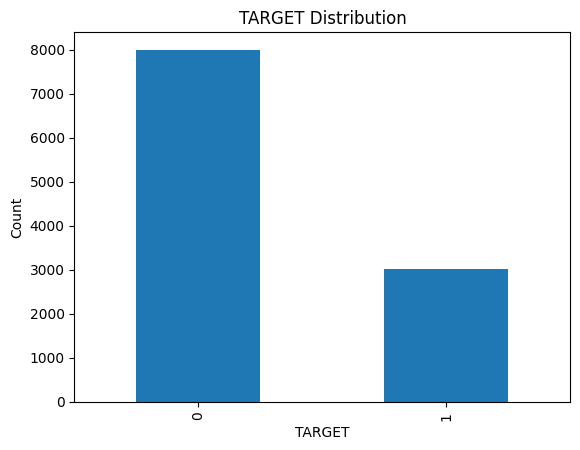

In [51]:
import matplotlib.pyplot as plt

cls_counts = df_clean[target_col].value_counts().sort_index()
cls_pct = (cls_counts / cls_counts.sum() * 100).round(2)
print("Class distribution (%):\n", cls_pct)

cls_counts.plot(kind='bar')
plt.title("TARGET Distribution")
plt.xlabel("TARGET")
plt.ylabel("Count")
plt.show()

Categorical features: level counts & bar plots

,count
loyalty,
Unknown,5048
3,2701
1,2019
2,1184
0,56


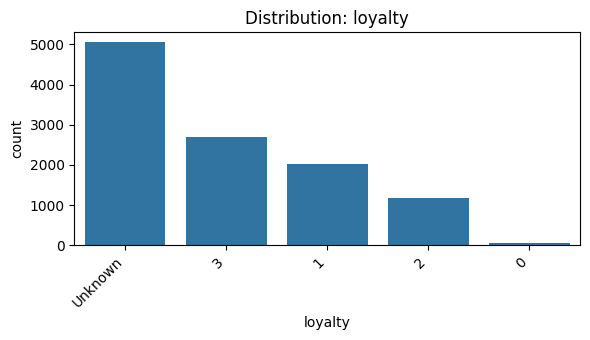

,count
prod_A,
1,6433
0,4575


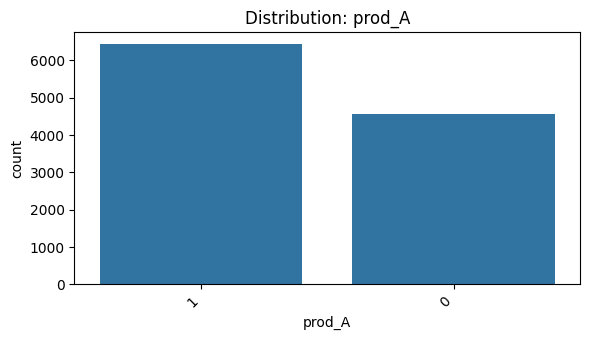

,count
type_A,
3,6410
0,4575
6,23


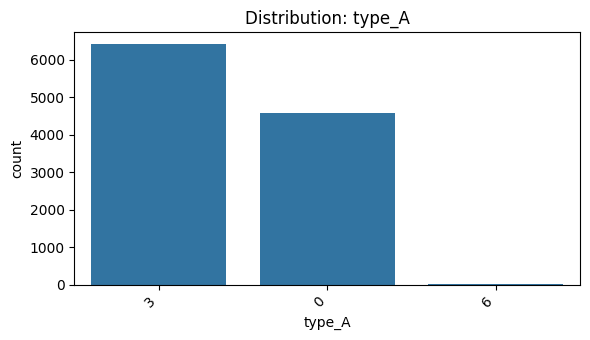

,count
type_B,
3,6695
0,3828
6,452
9,33


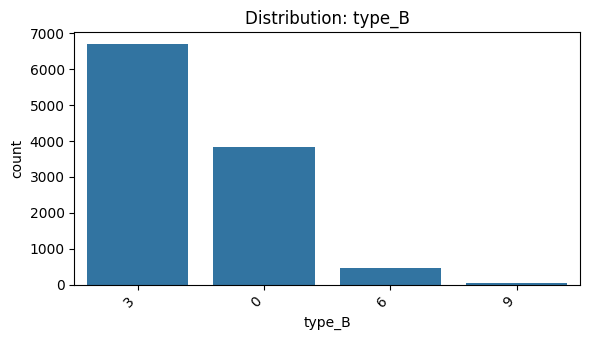

,count
prod_B,
1,7180
0,3828


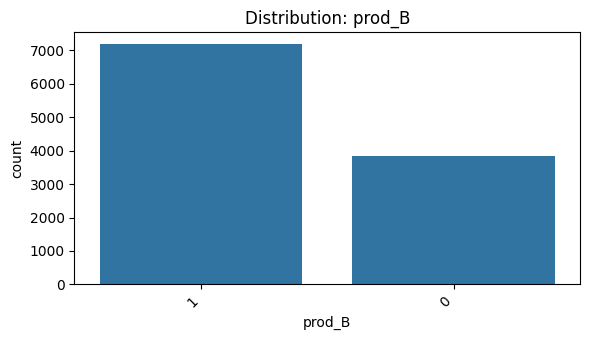

,count
city_reduced,
2,10769
Other,48
0,20
8,17
1,17
9,16
4,15
5,13
7,11


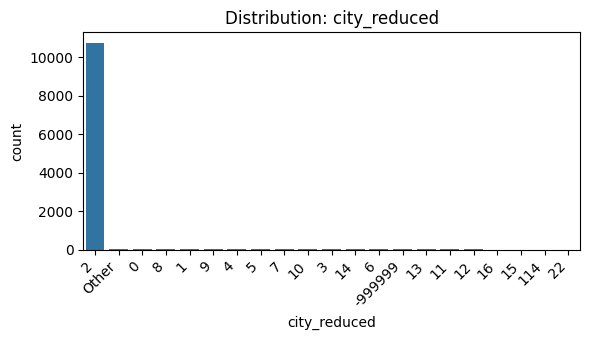

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in categorical_for_model:
    display(pd.DataFrame(df_clean[col].value_counts()).head(15))
    plt.figure(figsize=(6,3.5))
    sns.countplot(x=df_clean[col], order=df_clean[col].value_counts().index)
    plt.title(f"Distribution: {col}")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


Numeric features: summary + histograms & boxplots

,count,mean,std,min,25%,50%,75%,max
age,11008.0,34.844840,13.030936,5.000000,24.000000,31.000000,42.000000,100.000000
tenure_months,11008.0,14.791788,11.272981,3.000000,3.000000,15.000000,15.000000,75.000000
log_turnover_A,11008.0,5.908144,0.142926,5.707946,5.808833,5.894211,5.972709,7.366808
log_turnover_B,11008.0,5.591869,0.496276,5.304085,5.390450,5.463939,5.540320,8.640163


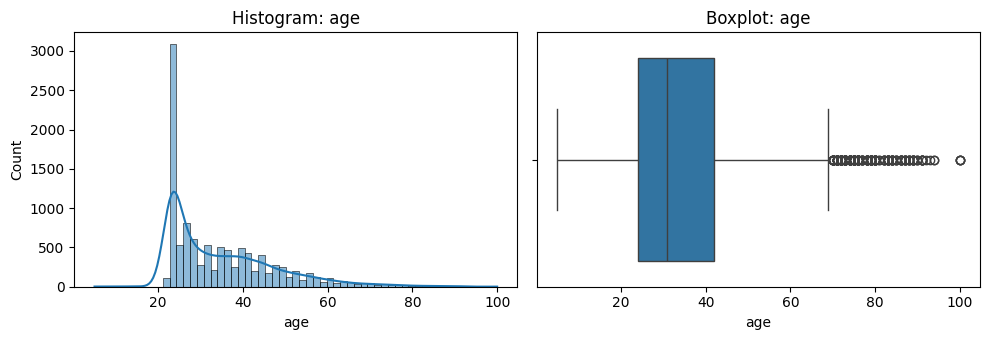

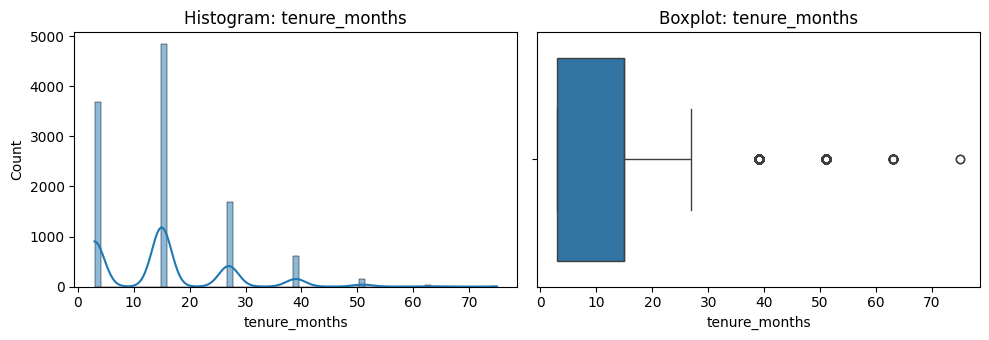

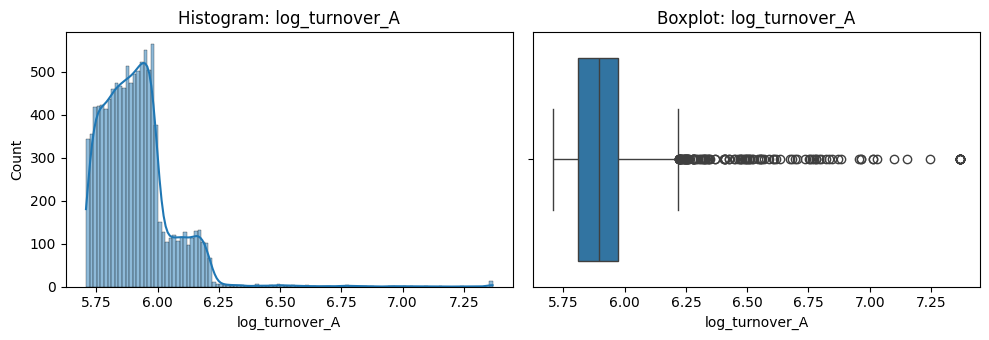

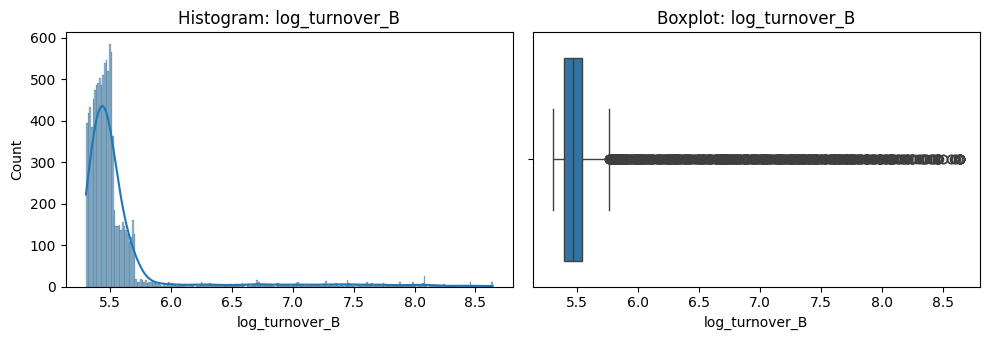

In [53]:
display(df_clean[numeric_for_model].describe().T)

for col in numeric_for_model:
    fig, ax = plt.subplots(1,2, figsize=(10,3.5))
    sns.histplot(df_clean[col], kde=True, ax=ax[0])
    ax[0].set_title(f"Histogram: {col}")
    sns.boxplot(x=df_clean[col], ax=ax[1])
    ax[1].set_title(f"Boxplot: {col}")
    plt.tight_layout()
    plt.show()

Correlation among numeric features

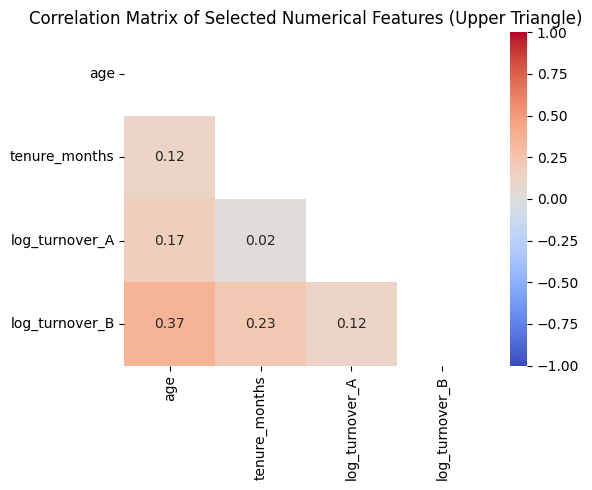

In [54]:
# Calculate the correlation matrix for the selected numerical columns
correlation_matrix_clean = df_clean[numeric_for_model].corr()

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(correlation_matrix_clean, dtype=bool))

# Plot the heatmap of the correlation matrix as a triangle
plt.figure(figsize=(6, 5))
sns.heatmap(correlation_matrix_clean, annot=True, cmap='coolwarm', fmt=".2f", mask=mask, vmin=-1, vmax=1)
plt.title("Correlation Matrix of Selected Numerical Features (Upper Triangle)")
plt.tight_layout()
plt.show()

Target association (quick univariate checks)

In [55]:

#Categorical vs Target
from scipy.stats import chi2_contingency

def cramers_v(confusion):
    chi2 = chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    phi2 = chi2 / n
    r,k = confusion.shape
    # bias correction
    phi2_corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    r_corr = r - ((r-1)**2)/(n-1)
    k_corr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2_corr / min((k_corr-1), (r_corr-1)))

cat_assoc = []
for col in categorical_for_model:
    ct = pd.crosstab(df_clean[col], df_clean[target_col])
    chi2, p, dof, _ = chi2_contingency(ct)
    cv = cramers_v(ct)
    cat_assoc.append({'feature': col, 'chi2_pvalue': p, 'cramers_v': cv})

pd.DataFrame(cat_assoc).sort_values('cramers_v', ascending=False)


,feature,chi2_pvalue,cramers_v
3,type_B,6.523923e-243,0.318828
4,prod_B,7.997447e-242,0.316391
2,type_A,9.808870e-207,0.293273
1,prod_A,1.581202e-207,0.292862
0,loyalty,1.421345e-136,0.239835
5,city_reduced,3.976650e-02,0.033486


Numeric vs TARGET

,feature,point_biserial_r,pvalue
2,log_turnover_A,0.358412,0.000000e+00
0,age,0.227528,3.029855e-129
3,log_turnover_B,-0.048171,4.272499e-07
1,tenure_months,-0.171396,2.434637e-73


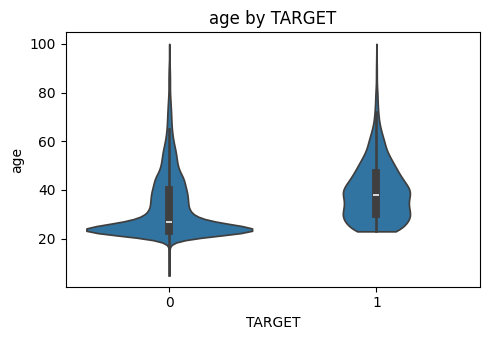

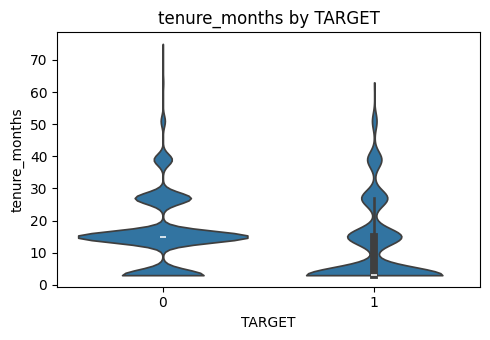

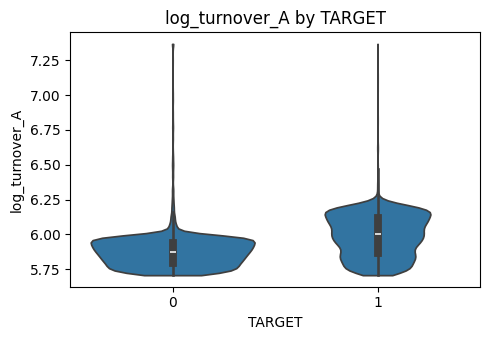

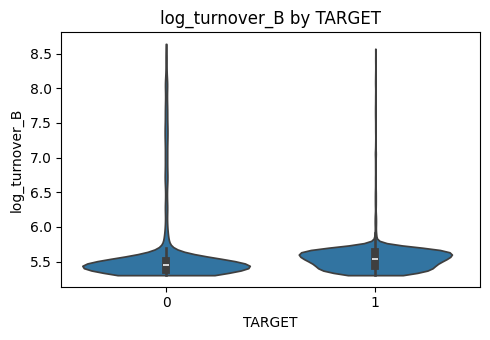

In [56]:
from scipy.stats import pearsonr

num_assoc = []
for col in numeric_for_model:
    r, p = pearsonr(df_clean[col], df_clean[target_col])
    g = df_clean.groupby(target_col)[col].agg(['mean','median','std','count']).T
    num_assoc.append({'feature': col, 'point_biserial_r': r, 'pvalue': p})

display(pd.DataFrame(num_assoc).sort_values('point_biserial_r', ascending=False))

# Optional: simple violin to visualize separation per numeric feature
for col in numeric_for_model:
    plt.figure(figsize=(5,3.5))
    sns.violinplot(x=df_clean[target_col], y=df_clean[col], cut=0)
    plt.title(f"{col} by TARGET")
    plt.tight_layout()
    plt.show()

Encoding readiness (no mixed types in categoricals)

In [57]:
def type_set(s):
    return {type(v).__name__ for v in s.dropna().unique()}

for c in categorical_for_model:
    print(f"{c}: {type_set(df_clean[c])}")  # should be {'str'}

for c in numeric_for_model:
    assert pd.api.types.is_numeric_dtype(df_clean[c]), f"{c} should be numeric"
print("Type checks passed.")

loyalty: {'str'}
prod_A: {'str'}
type_A: {'str'}
type_B: {'str'}
prod_B: {'str'}
city_reduced: {'str'}
Type checks passed.


Final modeling frame preview

In [58]:
df_ready = df_clean[[target_col] + categorical_for_model + numeric_for_model].copy()
print("df_ready shape:", df_ready.shape)
display(df_ready.head(10))


df_ready shape: (11008, 11)


,TARGET,loyalty,prod_A,type_A,type_B,prod_B,city_reduced,age,tenure_months,log_turnover_A,log_turnover_B
0,1,Unknown,0,0,0,0,2,66,3,5.812820,5.582447
1,1,1,1,3,3,1,2,45,39,5.980747,5.655660
2,1,1,1,3,6,1,2,42,27,5.838258,7.070375
3,1,Unknown,0,0,0,0,2,31,3,6.119765,5.494467
4,1,Unknown,0,0,0,0,2,62,3,5.954742,5.662990
5,1,3,1,3,3,1,2,24,15,6.134357,5.515312
6,1,Unknown,0,0,0,0,2,57,3,6.205494,5.379787
7,1,Unknown,0,0,0,0,2,32,3,6.160472,5.510233
8,1,Unknown,0,0,0,0,2,28,3,6.115269,5.536229
9,1,Unknown,0,0,0,0,2,30,3,5.858754,5.577059


In [59]:
# Check unique values and their counts in the 'TARGET' column of df_ready
target_unique_values = df_ready['TARGET'].unique()
target_value_counts = df_ready['TARGET'].value_counts()

print("Unique values in 'TARGET' column:")
display(target_unique_values)

print("\nValue counts for 'TARGET' column:")
display(target_value_counts)

Unique values in 'TARGET' column:


array([1, 0])


Value counts for 'TARGET' column:


,count
TARGET,
0,8000
1,3008


## **What to write in your Markdown (very short)**

Confirm no duplicates, data types are correct, and missingness is low/handled at modeling via imputers.

Summarize class imbalance and that you’ll address it with class_weight='balanced' and threshold tuning in modeling.

Note skew on spend variables is addressed via log_turnover_*.

Report 1–2 takeaways from Cramér’s V (categoricals) and point-biserial (numerics).

Confirm categoricals are strings → ready for OneHotEncoder(handle_unknown='ignore').

### Train-Test Split

In [60]:
from sklearn.model_selection import train_test_split

X = df_ready[categorical_for_model + numeric_for_model].copy()
y = df_ready[target_col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True).round(3))


Train: (8806, 10) | Test: (2202, 10)
Train class balance:
 TARGET
0    0.727
1    0.273
Name: proportion, dtype: float64


Preprocess (impute + OHE) — no leakage

In [61]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

num_tf = SimpleImputer(strategy='median')
cat_tf = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', num_tf, numeric_for_model),
        ('cat', cat_tf, categorical_for_model)
    ]
)

## Modeling

Three logisticRegression setups

In [63]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Define the Baseline Logistic Regression Model Pipeline
# This model uses default parameters (except max_iter and random_state) and no class weight balancing.
baseline_model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocess), # Use the preprocessor defined earlier
    ('classifier', LogisticRegression(max_iter=500, solver='liblinear', random_state=42))
])

print("Baseline model pipeline defined.")

Baseline model pipeline defined.


In [64]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Define the Balanced Logistic Regression Model Pipeline
# This model uses class_weight='balanced' to handle class imbalance.
balanced_model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocess), # Use the preprocessor defined earlier
    ('classifier', LogisticRegression(max_iter=500, solver='liblinear',
                                       class_weight='balanced', random_state=42))
])

print("Balanced model pipeline defined.")

Balanced model pipeline defined.


In [65]:
from sklearn.model_selection import GridSearchCV

# Define the base pipeline for tuning
# This pipeline includes the preprocessor and a Logistic Regression classifier
tuned_model_base = Pipeline(steps=[
    ('preprocessor', preprocess), # Use the preprocessor defined earlier
    ('classifier', LogisticRegression(max_iter=500, solver='liblinear', random_state=42))
])

# Define the parameter grid for GridSearchCV
param_grid = {
    'classifier__penalty': ['l1', 'l2'], # Penalty type
    'classifier__C': [0.25, 1.0, 4.0], # Inverse of regularization strength
    'classifier__class_weight': [None, 'balanced'] # Class weight options
}

# Define the GridSearchCV object
# tuned_model will find the best hyperparameters from param_grid using cross-validation
tuned_model = GridSearchCV(
    estimator=tuned_model_base, # The base pipeline to tune
    param_grid=param_grid, # The hyperparameters to search
    scoring='roc_auc', # The metric to optimize (AUC is suitable for imbalanced data)
    cv=5, # Number of cross-validation folds
    n_jobs=-1, # Use all available cores
    refit=True # Refit the best estimator on the whole training data
)

print("Tuned model pipeline with GridSearchCV defined.")

Tuned model pipeline with GridSearchCV defined.


Compare coefficients across models (same feature space)

In [67]:
from sklearn.metrics import roc_auc_score, confusion_matrix

# Dictionary to store models for easy iteration
models = {
    'Baseline Model': baseline_model_pipeline,
    'Balanced Model': balanced_model_pipeline,
    'Tuned Model': tuned_model
}

# Dictionary to store evaluation results
results = {}

# Train and evaluate each model
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train) # Train the model pipeline

    print(f"Evaluating {name}...")
    # Predict probabilities for ROC AUC
    y_prob = model.predict_proba(X_test)[:, 1]
    auc_score = roc_auc_score(y_test, y_prob)

    # Predict class labels for Confusion Matrix (using default threshold 0.5)
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    results[name] = {
        'AUC-ROC': auc_score,
        'Confusion Matrix': cm
    }

    print(f"{name} - AUC-ROC: {auc_score:.4f}")
    print(f"{name} - Confusion Matrix:\n{cm}\n")
    print("-" * 30)


Training Baseline Model...
Evaluating Baseline Model...
Baseline Model - AUC-ROC: 0.8135
Baseline Model - Confusion Matrix:
[[1491  109]
 [ 356  246]]

------------------------------
Training Balanced Model...
Evaluating Balanced Model...
Balanced Model - AUC-ROC: 0.8177
Balanced Model - Confusion Matrix:
[[1164  436]
 [ 145  457]]

------------------------------
Training Tuned Model...
Evaluating Tuned Model...
Tuned Model - AUC-ROC: 0.8315
Tuned Model - Confusion Matrix:
[[1217  383]
 [ 158  444]]

------------------------------


In [68]:
#Display results in a structured way (e.g., DataFrame)

auc_summary = {name: res['AUC-ROC'] for name, res in results.items()}
print("\nAUC-ROC Score Summary:")
display(pd.DataFrame.from_dict(auc_summary, orient='index', columns=['AUC-ROC Score']))

print("\nConfusion Matrix Summary (at threshold 0.5):")
for name, res in results.items():
    print(f"\n{name}:")
    display(pd.DataFrame(res['Confusion Matrix'], index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))


AUC-ROC Score Summary:


,AUC-ROC Score
Baseline Model,0.813497
Balanced Model,0.817651
Tuned Model,0.831458



Confusion Matrix Summary (at threshold 0.5):

Baseline Model:


,Predicted 0,Predicted 1
Actual 0,1491,109
Actual 1,356,246



Balanced Model:


,Predicted 0,Predicted 1
Actual 0,1164,436
Actual 1,145,457



Tuned Model:


,Predicted 0,Predicted 1
Actual 0,1217,383
Actual 1,158,444


In [69]:
from sklearn.metrics import accuracy_score, precision_score, f1_score, roc_auc_score

print("\nModel Evaluation Metrics Summary (at threshold 0.5):")

for name, res in results.items():
    print(f"\n{name}:")
    cm = res['Confusion Matrix']
    auc_score = res['AUC-ROC'] # AUC-ROC is already calculated

    # Extract values from confusion matrix
    tn, fp, fn, tp = cm.ravel()

    # Calculate metrics
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    # Handle cases where precision or F1 might be undefined (e.g., no positive predictions)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0 # Also calculate recall as it's part of classification report and F1
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0


    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    # print(f"  Recall: {recall:.4f}") # Recall is implicitly shown in confusion matrix and F1 depends on it
    print(f"  F1-Score: {f1:.4f}")
    print(f"  AUC-ROC: {auc_score:.4f}")
    print("-" * 30)


Model Evaluation Metrics Summary (at threshold 0.5):

Baseline Model:
  Accuracy: 0.7888
  Precision: 0.6930
  F1-Score: 0.5141
  AUC-ROC: 0.8135
------------------------------

Balanced Model:
  Accuracy: 0.7361
  Precision: 0.5118
  F1-Score: 0.6114
  AUC-ROC: 0.8177
------------------------------

Tuned Model:
  Accuracy: 0.7543
  Precision: 0.5369
  F1-Score: 0.6214
  AUC-ROC: 0.8315
------------------------------


In [70]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Dictionary to store the metrics for the comparison table
model_comparison_data = {}

# Calculate and store metrics for each model
for name, res in results.items():
    cm = res['Confusion Matrix']
    auc_score = res['AUC-ROC']

    # Extract values from confusion matrix
    tn, fp, fn, tp = cm.ravel()

    # Calculate metrics
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    # Handle cases where precision or F1 might be undefined
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    # Store the metrics in the dictionary
    model_comparison_data[name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': auc_score
    }

# Convert the dictionary to a pandas DataFrame
model_comparison_df = pd.DataFrame.from_dict(model_comparison_data, orient='index')

# Display the comparison table
print("Model Comparison - Evaluation Metrics (at threshold 0.5):")
display(model_comparison_df)

Model Comparison - Evaluation Metrics (at threshold 0.5):


,accuracy,precision,recall,f1,roc_auc
Baseline Model,0.788828,0.692958,0.408638,0.514107,0.813497
Balanced Model,0.736149,0.511758,0.759136,0.611371,0.817651
Tuned Model,0.754314,0.536880,0.737542,0.621414,0.831458


## KNN Models

In [74]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

# KNN Model 1: Using All Preprocessed Features
# This model uses the full preprocessing pipeline which includes scaling numerical features
# and one-hot encoding categorical features.
knn_model_1_pipeline = Pipeline(steps=[
    ('preprocessor', preprocess), # Uses the full preprocessor
    ('classifier', KNeighborsClassifier(n_neighbors=15)) # Example: using k=15
])

print("KNN Model 1 pipeline defined (using all preprocessed features).")

KNN Model 1 pipeline defined (using all preprocessed features).


### KNN Model 2: Using Only Numeric Features
This model will use only the numerical features after scaling. It uses a different preprocessing setup compared to Model 1.

In [75]:
# Define a preprocessor for numeric-only features
# This transformer will only apply StandardScaler to the numeric columns and drop others.
numeric_only_preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_for_model) # Only scale numeric features
    ],
    remainder='drop' # Drop all other columns (categorical)
)

# Define the second KNN Model Pipeline
# This pipeline uses the numeric-only preprocessor.
knn_model_2_pipeline = Pipeline(steps=[
    ('preprocessor', numeric_only_preprocess), # Uses the numeric-only preprocessor
    ('classifier', KNeighborsClassifier(n_neighbors=25, weights='distance', metric='minkowski', p=2)) # Example: using k=25 with different parameters
])

print("KNN Model 2 pipeline defined (using only numeric features).")

KNN Model 2 pipeline defined (using only numeric features).


Training the KNN models

In [76]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve
import matplotlib.pyplot as plt
import pandas as pd

# Dictionary to store KNN models for easy iteration and comparison
knn_models = {
    'KNN Model 1 (All Features)': knn_model_1_pipeline,
    'KNN Model 2 (Numeric Only)': knn_model_2_pipeline
}

# Dictionary to store evaluation results for KNN models
knn_results = {}

# Train and evaluate each KNN model
print("Evaluating KNN Models:")
for name, model in knn_models.items():
    print(f"\nTraining and Evaluating {name}...")

    # Train the model pipeline
    model.fit(X_train, y_train)

    # Predict probabilities for ROC AUC
    y_prob = model.predict_proba(X_test)[:, 1]
    auc_score = roc_auc_score(y_test, y_prob)

    # Predict class labels for other metrics (using default threshold 0.5)
    y_pred = model.predict(X_test)

    # Calculate additional metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)


    # Store the metrics
    knn_results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'AUC-ROC': auc_score,
        'Confusion Matrix': cm
    }

    print(f"  AUC-ROC: {auc_score:.4f}")
    print(f"  Confusion Matrix:\n{cm}")
    print(f"  Classification Report:\n{classification_report(y_test, y_pred)}")


# Display comparison table
print("\n--- KNN Model Comparison - Evaluation Metrics (at threshold 0.5) ---")
knn_comparison_data = {}
for name, metrics in knn_results.items():
    knn_comparison_data[name] = {
        'Accuracy': metrics['Accuracy'],
        'Precision': metrics['Precision'],
        'Recall': metrics['Recall'],
        'F1-Score': metrics['F1-Score'],
        'AUC-ROC': metrics['AUC-ROC']
    }

knn_comparison_df = pd.DataFrame.from_dict(knn_comparison_data, orient='index')
display(knn_comparison_df)


Evaluating KNN Models:

Training and Evaluating KNN Model 1 (All Features)...
  AUC-ROC: 0.8707
  Confusion Matrix:
[[1547   53]
 [ 307  295]]
  Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.97      0.90      1600
           1       0.85      0.49      0.62       602

    accuracy                           0.84      2202
   macro avg       0.84      0.73      0.76      2202
weighted avg       0.84      0.84      0.82      2202


Training and Evaluating KNN Model 2 (Numeric Only)...
  AUC-ROC: 0.9172
  Confusion Matrix:
[[1568   32]
 [ 233  369]]
  Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.98      0.92      1600
           1       0.92      0.61      0.74       602

    accuracy                           0.88      2202
   macro avg       0.90      0.80      0.83      2202
weighted avg       0.88      0.88      0.87      2202


--- KNN Model Comparison - Evalu

,Accuracy,Precision,Recall,F1-Score,AUC-ROC
KNN Model 1 (All Features),0.836512,0.847701,0.490033,0.621053,0.870654
KNN Model 2 (Numeric Only),0.879655,0.920200,0.612957,0.735793,0.917209


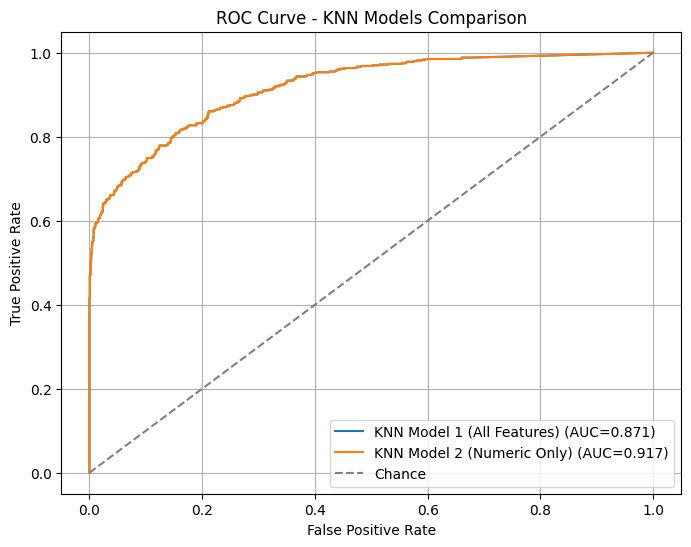

In [77]:
# Plot combined ROC curves
plt.figure(figsize=(8, 6))
for name, metrics in knn_results.items():
    y_prob = model.predict_proba(X_test)[:, 1] # Use the model from the loop
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={metrics['AUC-ROC']:.3f})")

plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Chance')
plt.title('ROC Curve - KNN Models Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.show()

### SVM Models

In [79]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

In [80]:
# Initialize the list to store SVM models for plotting
models_svm = []

# Assuming 'preprocess' is the full preprocessing pipeline defined earlier
full_preprocess = preprocess

#### SVM-1: Linear kernel + class_weight='balanced' (handles imbalance)

In [81]:
# SVM-1: Linear kernel + class_weight='balanced' (handles imbalance)
# This model uses the full preprocessing pipeline with a linear kernel and balanced class weights.
svm_linear_pipeline = Pipeline(steps=[
    ('prep', full_preprocess),
    ('clf',  SVC(kernel='linear', class_weight='balanced', probability=True, random_state=42))
])

# Train the pipeline on the training data
print("Training SVM-Linear (balanced)...")
svm_linear_pipeline.fit(X_train, y_train)
print("SVM-Linear (balanced) trained.")

# Predict probabilities and labels on the test set
y_prob_svm_lin = svm_linear_pipeline.predict_proba(X_test)[:,1]
y_pred_svm_lin = (y_prob_svm_lin >= 0.50).astype(int)

# Calculate evaluation metrics
auc_svm_lin = roc_auc_score(y_test, y_prob_svm_lin)

# Append results to the models_svm list
models_svm.append(('SVM-Linear(balanced)', svm_linear_pipeline, y_prob_svm_lin, auc_svm_lin))


print("\n=== SVM-Linear (balanced) ===")
print("AUC:", round(auc_svm_lin, 3))
print("Confusion matrix @0.50:\n", confusion_matrix(y_test, y_pred_svm_lin))
print(classification_report(y_test, y_pred_svm_lin, digits=3))

Training SVM-Linear (balanced)...
SVM-Linear (balanced) trained.

=== SVM-Linear (balanced) ===
AUC: 0.832
Confusion matrix @0.50:
 [[1497  103]
 [ 310  292]]
              precision    recall  f1-score   support

           0      0.828     0.936     0.879      1600
           1      0.739     0.485     0.586       602

    accuracy                          0.812      2202
   macro avg      0.784     0.710     0.732      2202
weighted avg      0.804     0.812     0.799      2202



In [78]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np

# Assuming 'preprocess' is the full preprocessing pipeline defined earlier
full_preprocess = preprocess

### SVM-2: RBF kernel with tuned C/gamma (different transformation: non-linear boundary)

In [82]:
# SVM-2: RBF kernel with tuned C/gamma (different transformation: non-linear boundary)
# This model uses the full preprocessing pipeline with an RBF kernel and specific C/gamma parameters.
svm_rbf_pipeline = Pipeline(steps=[
    ('prep', full_preprocess),
    ('clf',  SVC(kernel='rbf', C=2.0, gamma='scale', class_weight=None, probability=True, random_state=42))
])

# Train the pipeline on the training data
print("\nTraining SVM-RBF (C=2.0)...")
svm_rbf_pipeline.fit(X_train, y_train)
print("SVM-RBF (C=2.0) trained.")

# Predict probabilities and labels on the test set
y_prob_svm_rbf = svm_rbf_pipeline.predict_proba(X_test)[:,1]
y_pred_svm_rbf = (y_prob_svm_rbf >= 0.50).astype(int)

# Calculate evaluation metrics
auc_svm_rbf = roc_auc_score(y_test, y_prob_svm_rbf)

# Append results to the models_svm list (defined in the first SVM cell)
models_svm.append(('SVM-RBF(C=2.0)', svm_rbf_pipeline, y_prob_svm_rbf, auc_svm_rbf))


print("\n=== SVM-RBF (C=2.0) ===")
print("AUC:", round(auc_svm_rbf, 3))
print("Confusion matrix @0.50:\n", confusion_matrix(y_test, y_pred_svm_rbf))
print(classification_report(y_test, y_pred_svm_rbf, digits=3))


Training SVM-RBF (C=2.0)...
SVM-RBF (C=2.0) trained.

=== SVM-RBF (C=2.0) ===
AUC: 0.798
Confusion matrix @0.50:
 [[1469  131]
 [ 334  268]]
              precision    recall  f1-score   support

           0      0.815     0.918     0.863      1600
           1      0.672     0.445     0.535       602

    accuracy                          0.789      2202
   macro avg      0.743     0.682     0.699      2202
weighted avg      0.776     0.789     0.774      2202



In [83]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Dictionary to store evaluation results for SVM models
svm_results_comparison = {}

# Calculate and store metrics for each SVM model
for name, model, y_prob, auc_score in models_svm:
    # Predict class labels using a 0.5 threshold
    y_pred = (y_prob >= 0.5).astype(int)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred) # Calculate confusion matrix as well if needed later

    # Store the metrics
    svm_results_comparison[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'AUC-ROC': auc_score,
        'Confusion Matrix': cm # Storing CM for potential later use
    }

# Convert the dictionary to a pandas DataFrame
svm_comparison_df = pd.DataFrame.from_dict(svm_results_comparison, orient='index')

# Display the comparison table
print("--- SVM Model Comparison - Evaluation Metrics (at threshold 0.5) ---")
display(svm_comparison_df)

# Optional: Display Confusion Matrices
print("\nConfusion Matrix Summary (at threshold 0.5):")
for name, metrics in svm_results_comparison.items():
    print(f"\n{name}:")
    display(pd.DataFrame(metrics['Confusion Matrix'], index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

--- SVM Model Comparison - Evaluation Metrics (at threshold 0.5) ---


,Accuracy,Precision,Recall,F1-Score,AUC-ROC,Confusion Matrix
SVM-Linear(balanced),0.812443,0.739241,0.485050,0.585757,0.832232,"[[1497, 103], [310, 292]]"
SVM-RBF(C=2.0),0.788828,0.671679,0.445183,0.535465,0.798148,"[[1469, 131], [334, 268]]"



Confusion Matrix Summary (at threshold 0.5):

SVM-Linear(balanced):


,Predicted 0,Predicted 1
Actual 0,1497,103
Actual 1,310,292



SVM-RBF(C=2.0):


,Predicted 0,Predicted 1
Actual 0,1469,131
Actual 1,334,268


## Comparing Coefficients Across Models